# **Introduction**

This project focuses on building a Machine Learning Classification model to predict the type of weather based on meteorological conditions.

The dataset used is the Seattle Weather Dataset, which contains weather information such as precipitation, temperature, and wind speed.

The goal is to classify weather into categories such as:

* Rain
* Sun
* Fog
* Drizzle
* Snow

Machine Learning algorithms are trained on historical weather data to predict the weather type accurately.

## **Objective**

The objectives of this project are:

* To analyze the Seattle weather dataset.
* To preprocess and clean the data.
* To visualize important weather patterns.
* To train classification models.
* To evaluate model performance using classification metrics.
* To compare algorithms and select the best-performing model.

## **Dataset Information**

Dataset Name: **Seattle Weather Dataset**

Features:

* `date`	Date of observation
* `precipitation`	Amount of rainfall
* `temp_max`	Maximum temperature
* `temp_min`	Minimum temperature
* `wind`	Wind speed
* `weather`	Target variable (weather type)


> **Target Variable:** weather

> **Total Records:** 1461 rows

## **Importing Libraries**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## **Loading the Dataset**

In [6]:
df = pd.read_csv(r'/Users/himanshuneeraj/Documents/AAFT Classes /Semester -2 /Machine Learning /H project/seattle-weather.csv')
df
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


## **Basic Dataset Information**

In [7]:
print(df.shape)
print(df.info())
print(df.describe())

(1461, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB
None
       precipitation     temp_max     temp_min         wind
count    1461.000000  1461.000000  1461.000000  1461.000000
mean        3.029432    16.439083     8.234771     3.241136
std         6.680194     7.349758     5.023004     1.437825
min         0.000000    -1.600000    -7.100000     0.400000
25%         0.000000    10.600000     4.400000     2.200000
50%         0.000000    15.600000     8.300000     3.000000
75%         2.800000    22.200000    12.200000     4.0

## **Checking Missing Values**

In [8]:
print(df.isnull().sum())

date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64


## **Exploratory Data Analysis (EDA)**

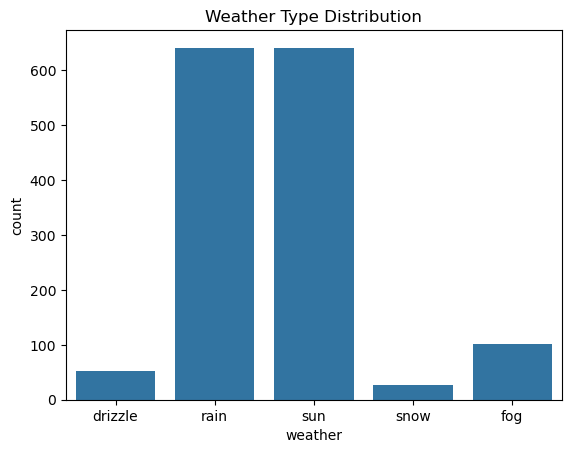

In [9]:
# Weather Distribution

sns.countplot(x='weather', data=df)
plt.title('Weather Type Distribution')
plt.show()

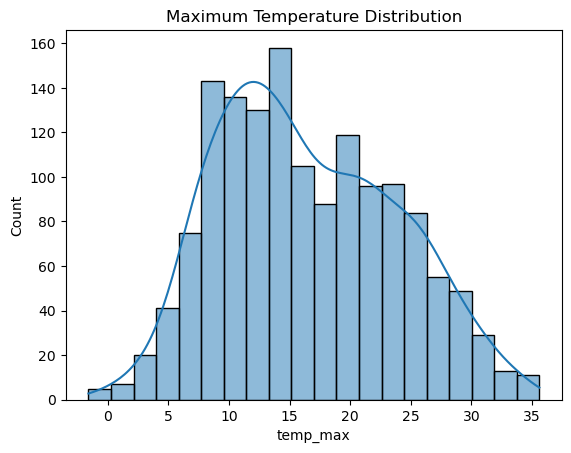

In [10]:
# Temperature Distribution

sns.histplot(df['temp_max'], bins=20, kde=True)
plt.title('Maximum Temperature Distribution')
plt.show()

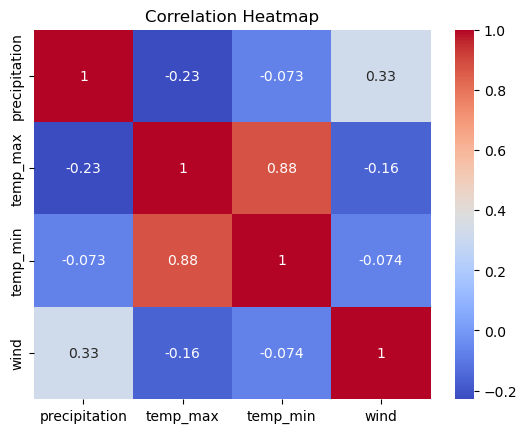

In [11]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## **Data Preprocessing**

### Convert Date Column

In [12]:
df['date'] = pd.to_datetime(df['date'])

# Extract useful date features

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

# Drop original date column

df.drop('date', axis=1, inplace=True)

### Define Features and Target

In [13]:
X = df.drop('weather', axis=1)
y = df['weather']

### Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Feature Scaling

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **Model Building**

### Logistic Regression

In [16]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print('Logistic Regression Accuracy:', accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7952218430034129


### K-Nearest Neighbors (KNN)

In [17]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print('KNN Accuracy:', accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.6962457337883959


### Decision Tree Classifier

In [18]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print('Decision Tree Accuracy:', accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7610921501706485


### Random Forest Classifier

In [19]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8532423208191127


## **Model Evaluation**

In [20]:
# Classification Report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

     drizzle       0.67      0.22      0.33         9
         fog       0.86      0.24      0.38        25
        rain       0.95      0.93      0.94       120
        snow       0.67      0.25      0.36         8
         sun       0.79      0.98      0.88       131

    accuracy                           0.85       293
   macro avg       0.79      0.52      0.58       293
weighted avg       0.85      0.85      0.83       293



## **Accuracy Comparison**

In [21]:
results = {
    'Logistic Regression': accuracy_score(y_test, lr_pred),
    'KNN': accuracy_score(y_test, knn_pred),
    'Decision Tree': accuracy_score(y_test, dt_pred),
    'Random Forest': accuracy_score(y_test, rf_pred)
}

for model, score in results.items():
    print(model, ':', score)

Logistic Regression : 0.7952218430034129
KNN : 0.6962457337883959
Decision Tree : 0.7610921501706485
Random Forest : 0.8532423208191127


## **Best Model Selection**

The model with the highest accuracy is selected as the best model.

In most cases, Random Forest performs better because:

- It handles non-linear relationships.
- It reduces overfitting.
- It works well with structured datasets.
- It combines multiple decision trees for improved prediction.

## **Conclusion**

This project successfully developed Machine Learning classification models to predict weather conditions using the Seattle Weather Dataset.

Key outcomes:

- Data preprocessing improved model performance.
- Feature scaling helped distance-based algorithms like KNN.
- Random Forest achieved the best overall performance.
- Classification metrics provided detailed evaluation of the models.

This project demonstrates the practical application of Machine Learning classification techniques in weather forecasting.